In [1]:
import autograd.numpy as np
import autograd.numpy.random as npr
import matplotlib.pyplot as plt
# GLM class
import os
from autograd.scipy.special import logsumexp
# Import useful functions from ssm package
from ssm.util import ensure_args_are_lists
from ssm.optimizers import adam, bfgs, rmsprop, sgd
import ssm.stats as stats
npr.seed(65)

In [2]:
class glm(object):
    def __init__(self, M, C):
        """
        @param C:  number of classes in the categorical observations
        """
        self.M = M
        self.C = C
        # Parameters linking input to state distribution
        self.Wk = npr.randn(1, C - 1, M + 1)

    @property
    def params(self):
        return self.Wk

    @params.setter
    def params(self, value):
        self.Wk = value

    def log_prior(self):
        return 0

    # Calculate time dependent logits - output is matrix of size Tx1xC
    # Input is size TxM
    def calculate_logits(self, input):
        # Update input to include offset term:
        input = np.append(input, np.ones((input.shape[0], 1)), axis=1)
        # Add additional row (of zeros) to second dimension of self.Wk
        Wk_tranpose = np.transpose(self.Wk, (1, 0, 2))
        Wk = np.transpose(
            np.vstack([
                Wk_tranpose,
                np.zeros((1, Wk_tranpose.shape[1], Wk_tranpose.shape[2]))
            ]), (1, 0, 2))
        # Input effect; transpose so that output has dims TxKxC
        time_dependent_logits = np.transpose(np.dot(Wk, input.T), (2, 0, 1))
        time_dependent_logits = time_dependent_logits - logsumexp(
            time_dependent_logits, axis=2, keepdims=True)
        return time_dependent_logits

    # Calculate log-likelihood of observed data
    def log_likelihoods(self, data, input, mask, tag):
        time_dependent_logits = self.calculate_logits(input)
        mask = np.ones_like(data, dtype=bool) if mask is None else mask
        return stats.categorical_logpdf(data[:, None, :],
                                        time_dependent_logits[:, :, None, :],
                                        mask=mask[:, None, :])

    # log marginal likelihood of data
    @ensure_args_are_lists
    def log_marginal(self, datas, inputs, masks, tags):
        elbo = self.log_prior()
        for data, input, mask, tag in zip(datas, inputs, masks, tags):
            lls = self.log_likelihoods(data, input, mask, tag)
            elbo += np.sum(lls)
        return elbo

    @ensure_args_are_lists
    def fit_glm(self,
                datas,
                inputs,
                masks,
                tags,
                num_iters=1000,
                optimizer="bfgs",
                **kwargs):
        optimizer = dict(adam=adam, bfgs=bfgs, rmsprop=rmsprop,
                         sgd=sgd)[optimizer]

        def _objective(params, itr):
            self.params = params
            obj = self.log_marginal(datas, inputs, masks, tags)
            return -obj

        self.params = optimizer(_objective,
                                self.params,
                                num_iters=num_iters,
                                **kwargs)

In [3]:
def load_data(animal_file):
    container = np.load(animal_file, allow_pickle=True)
    data = [container[key] for key in container]
    inpt = data[0]
    y = data[1]
    session = data[2]
    return inpt, y, session


def fit_glm(inputs, datas, M, C):
    new_glm = glm(M, C)
    new_glm.fit_glm(datas, inputs, masks=None, tags=None)
    # Get loglikelihood of training data:
    loglikelihood_train = new_glm.log_marginal(datas, inputs, None, None)
    recovered_weights = new_glm.Wk
    return loglikelihood_train, recovered_weights


# Append column of zeros to weights matrix in appropriate location
def append_zeros(weights):
    weights_tranpose = np.transpose(weights, (1, 0, 2))
    weights = np.transpose(
        np.vstack([
            weights_tranpose,
            np.zeros((1, weights_tranpose.shape[1], weights_tranpose.shape[2]))
        ]), (1, 0, 2))
    return weights


def load_session_fold_lookup(file_path):
    container = np.load(file_path, allow_pickle=True)
    data = [container[key] for key in container]
    session_fold_lookup_table = data[0]
    return session_fold_lookup_table


def load_animal_list(list_file):
    container = np.load(list_file, allow_pickle=True)
    data = [container[key] for key in container]
    animal_list = data[0]
    return animal_list


def plot_input_vectors(Ws,
                       figure_directory,
                       title='true',
                       save_title="true",
                       labels_for_plot=[]):
    K = Ws.shape[0]
    K_prime = Ws.shape[1]
    M = Ws.shape[2] - 1
    fig = plt.figure(figsize=(7, 9), dpi=80, facecolor='w', edgecolor='k')
    plt.subplots_adjust(left=0.15,
                        bottom=0.27,
                        right=0.95,
                        top=0.95,
                        wspace=0.3,
                        hspace=0.3)

    for j in range(K):
        for k in range(K_prime - 1):
            # plt.subplot(K, K_prime, 1+j*K_prime+k)
            plt.plot(range(M + 1), -Ws[j][k], marker='o')
            plt.plot(range(-1, M + 2), np.repeat(0, M + 3), 'k', alpha=0.2)
            plt.axhline(y=0, color="k", alpha=0.5, ls="--")
            if len(labels_for_plot) > 0:
                plt.xticks(list(range(0, len(labels_for_plot))),
                           labels_for_plot,
                           rotation='90',
                           fontsize=12)
            else:
                plt.xticks(list(range(0, 3)),
                           ['Stimulus', 'Past Choice', 'Bias'],
                           rotation='90',
                           fontsize=12)
            plt.ylim((-3, 6))

    fig.text(0.04,
             0.5,
             "Weight",
             ha="center",
             va="center",
             rotation=90,
             fontsize=15)
    fig.suptitle("GLM Weights: " + title, y=0.99, fontsize=14)
    fig.savefig(figure_directory + 'glm_weights_' + save_title + '.png')
    plt.close()

c:\users\jasmine\documents\github\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
c:\users\jasmine\documents\github\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
c:\users\jasmine\documents\github\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
c:\users\jasmine\documents\github\ssm\ssm\optimizers.py:146: UserWarning: BFGS failed with message:
Desired error not necessarily achieved due to precision loss.
  warn("{} failed with message:\n{}".format(method, result.message))
c:\users\jasmine\documents\github\ssm\ssm\optimizers.py:146: UserWarning: BF

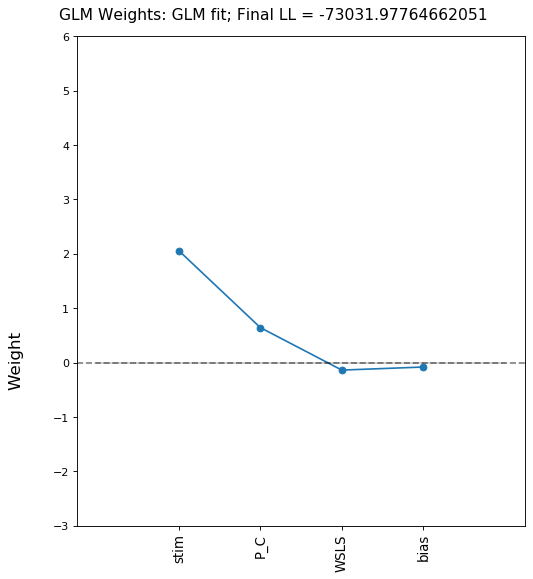

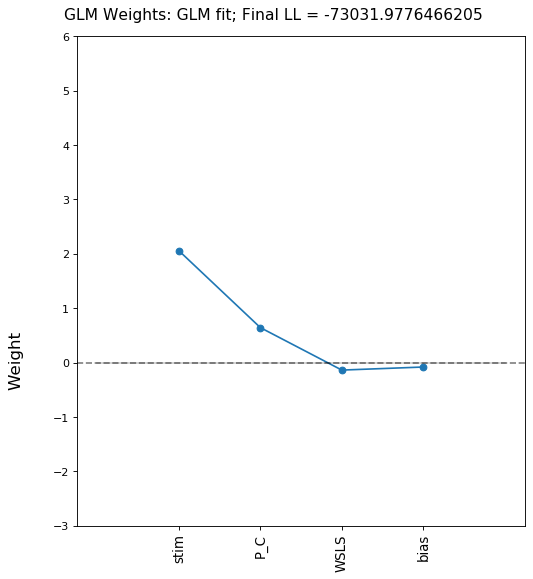

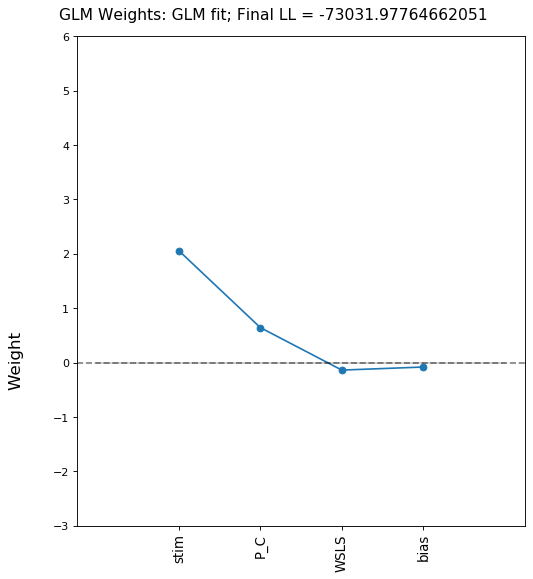

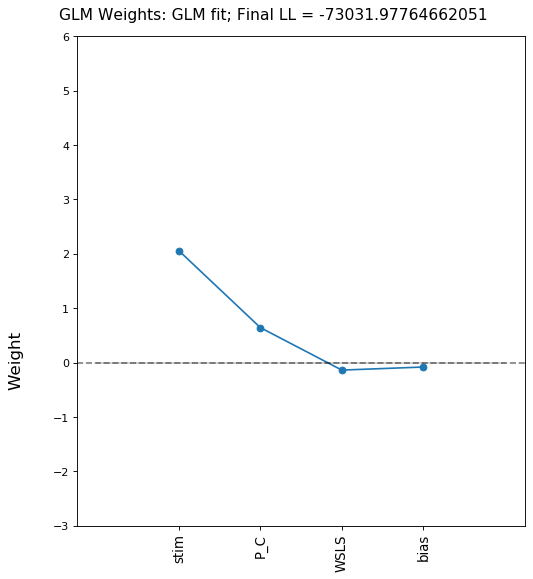

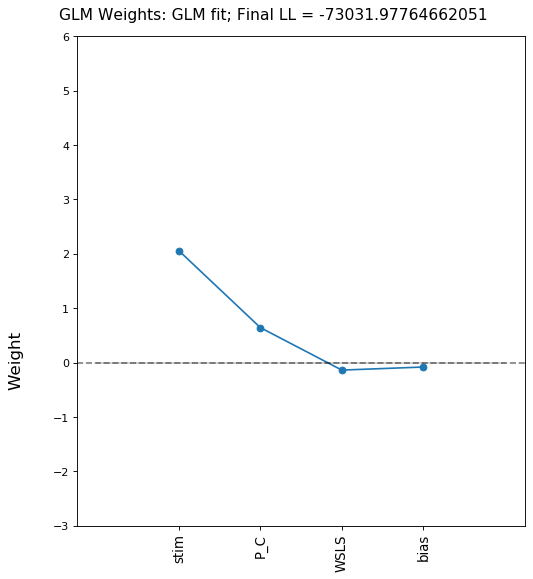

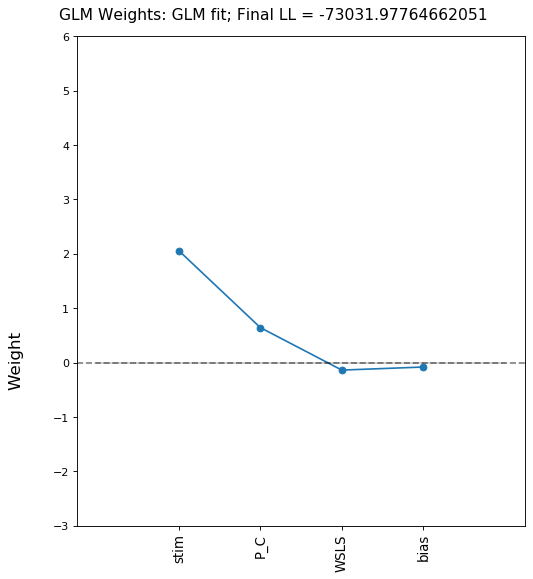

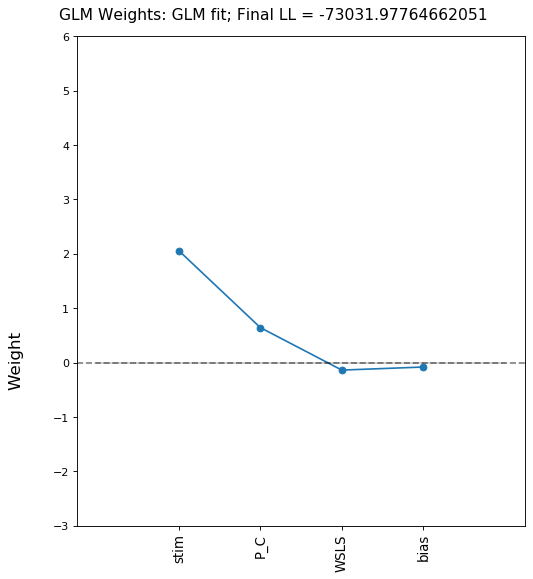

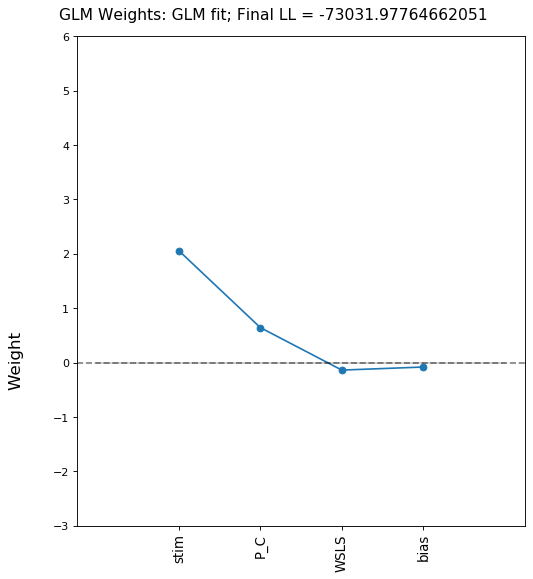

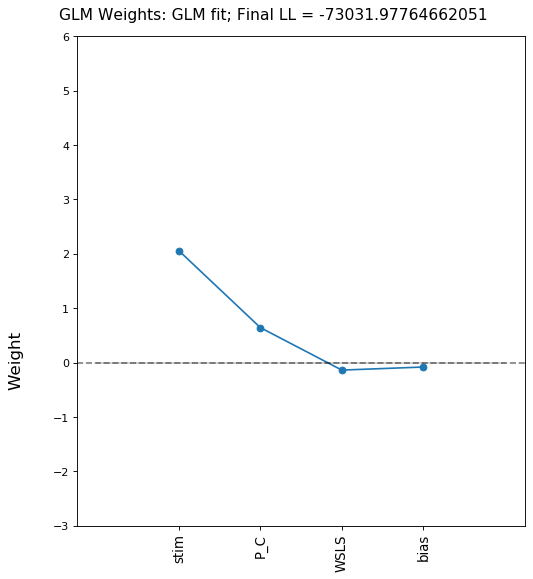

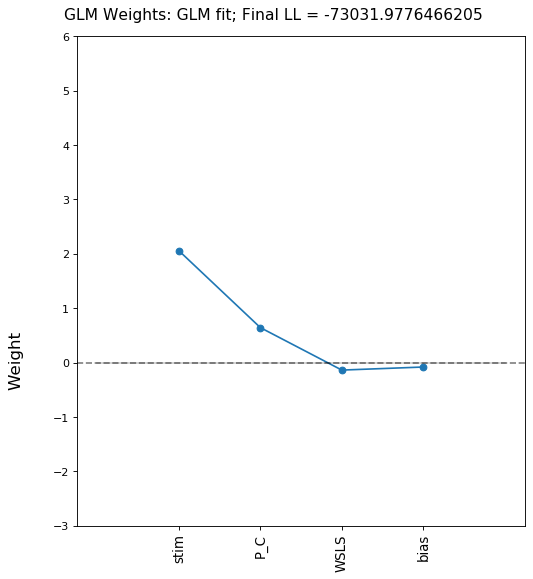

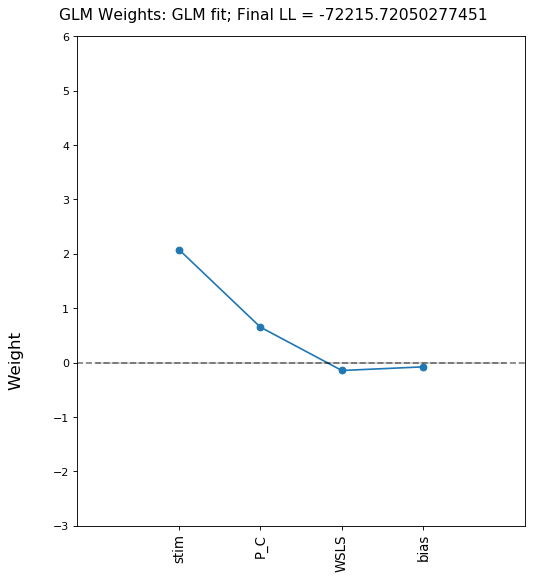

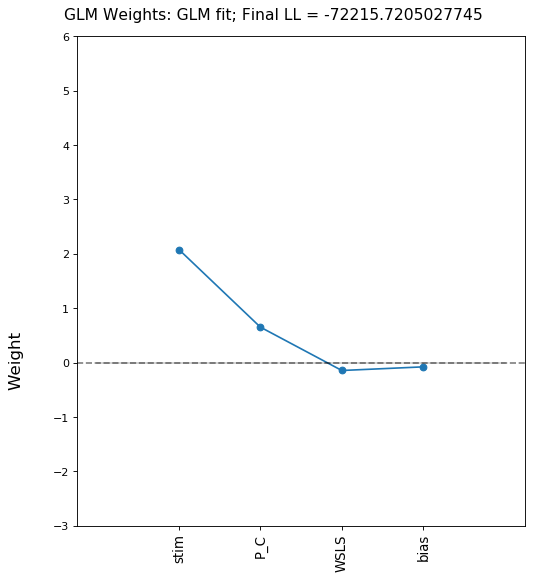

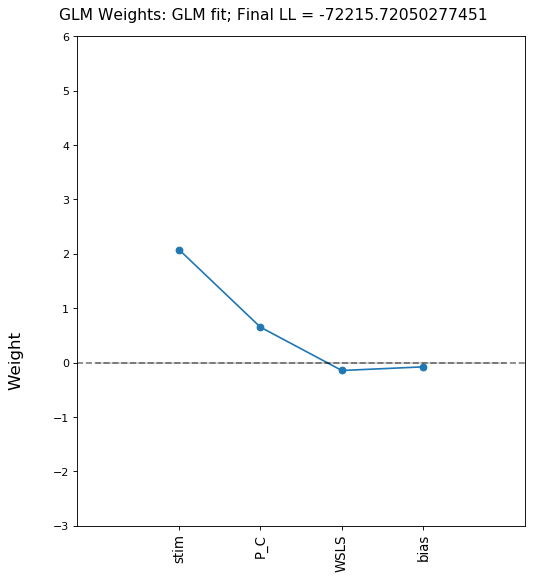

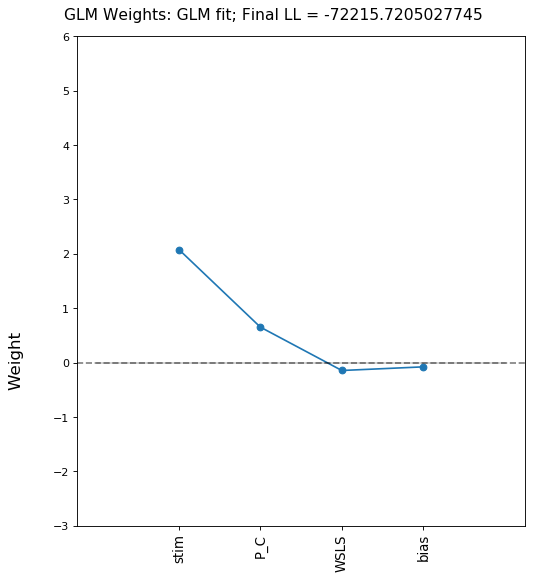

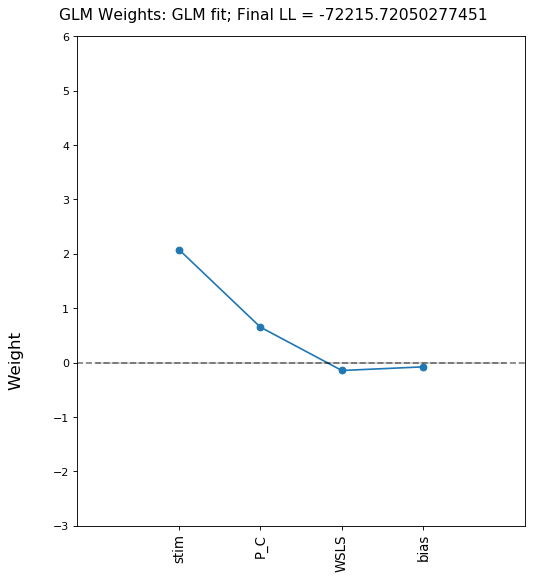

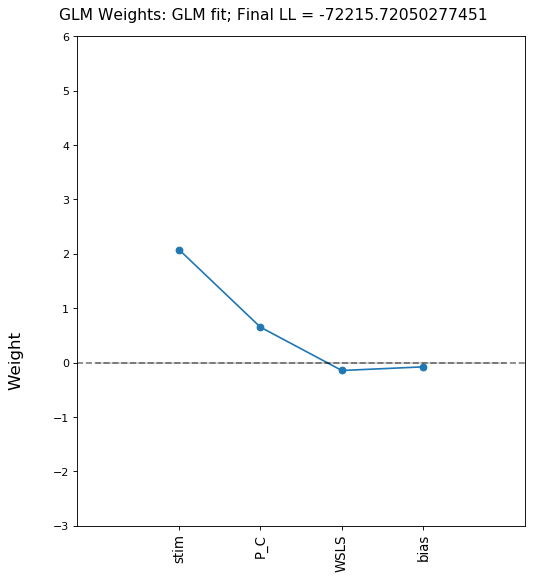

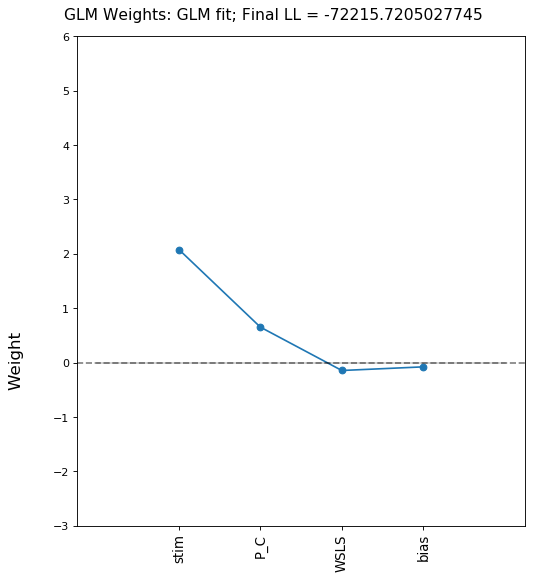

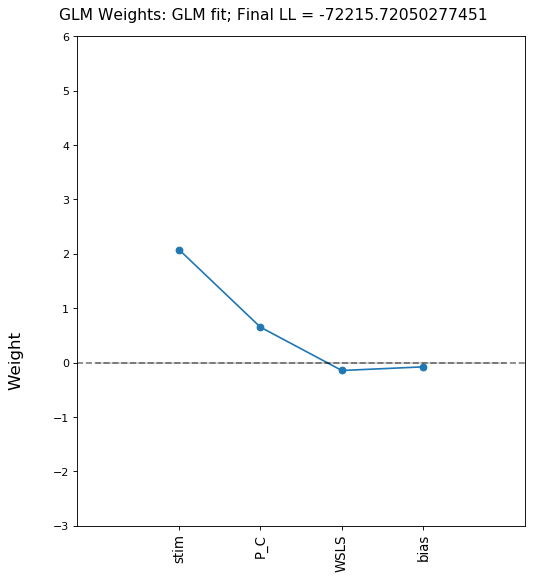

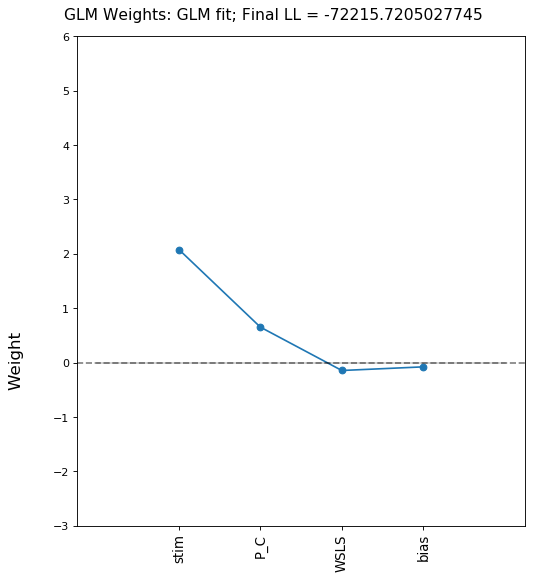

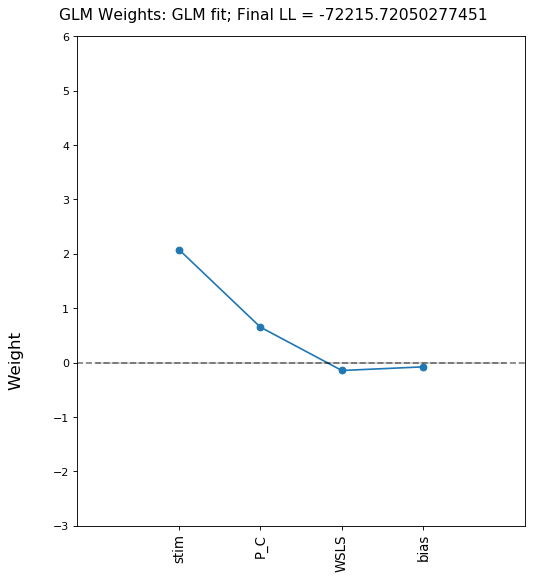

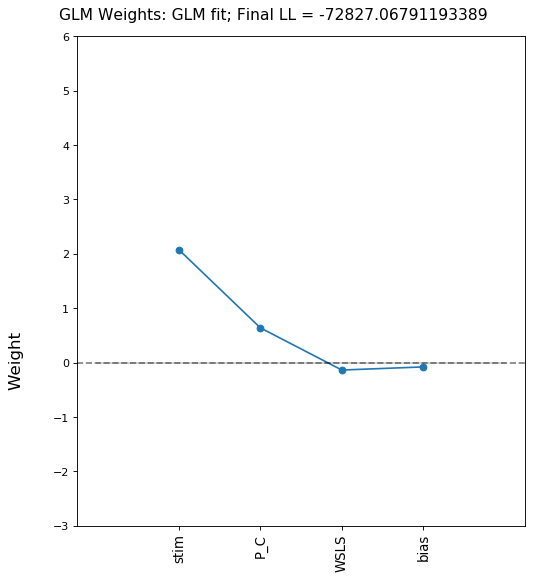

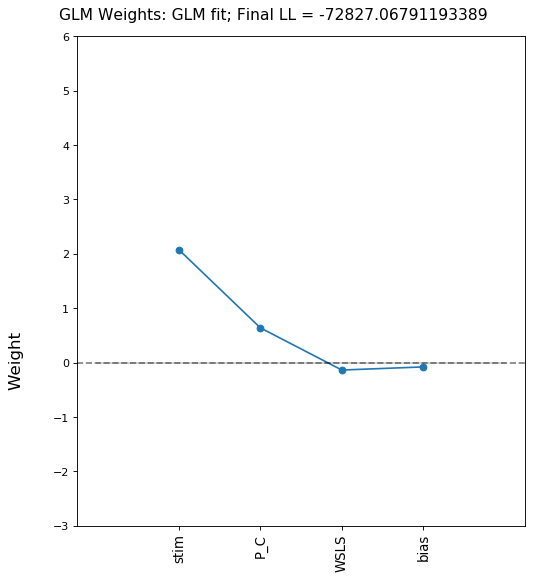

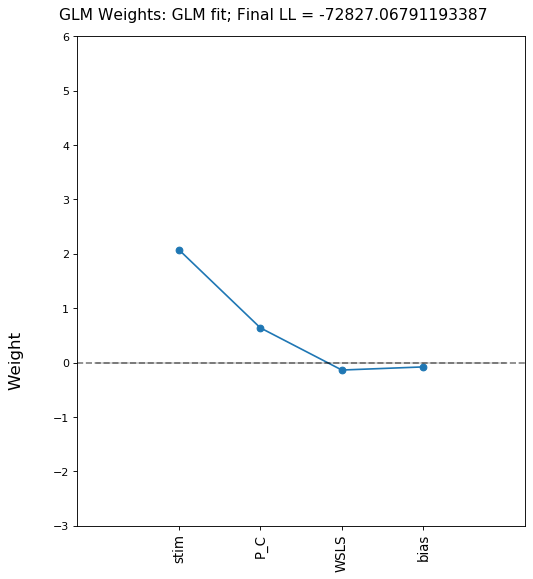

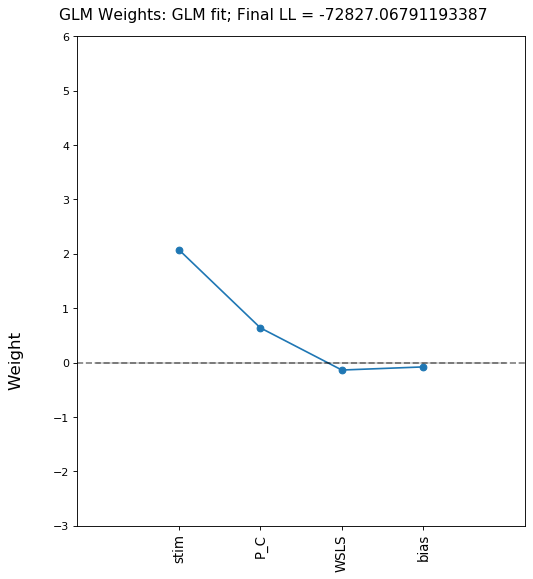

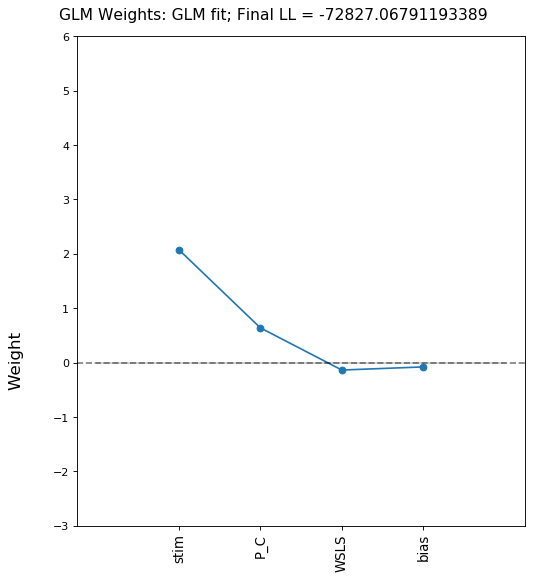

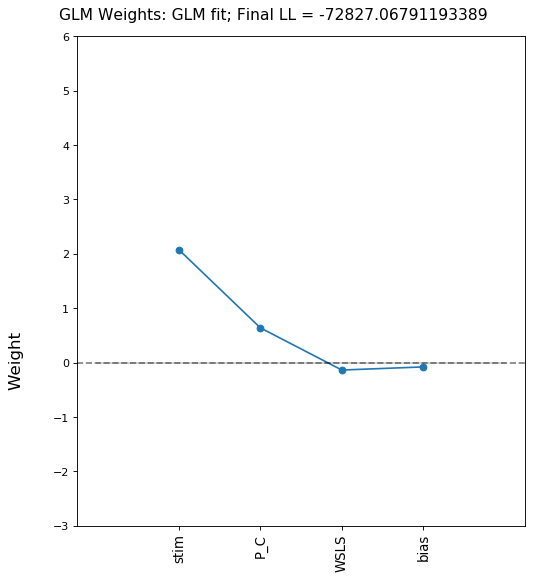

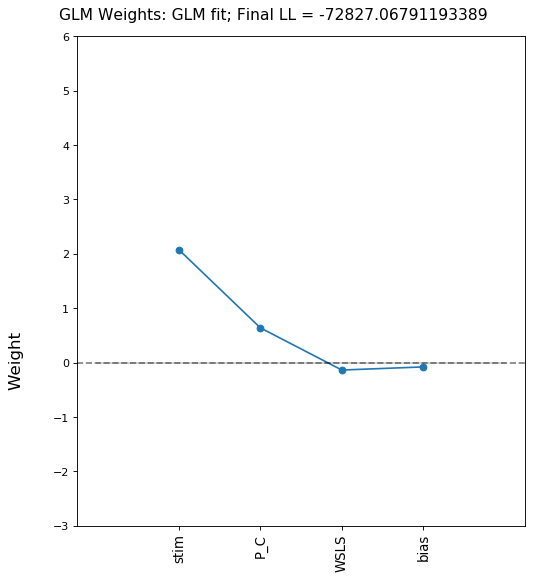

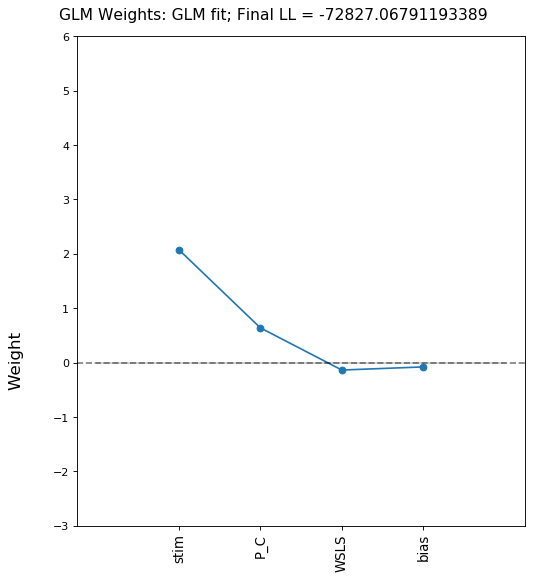

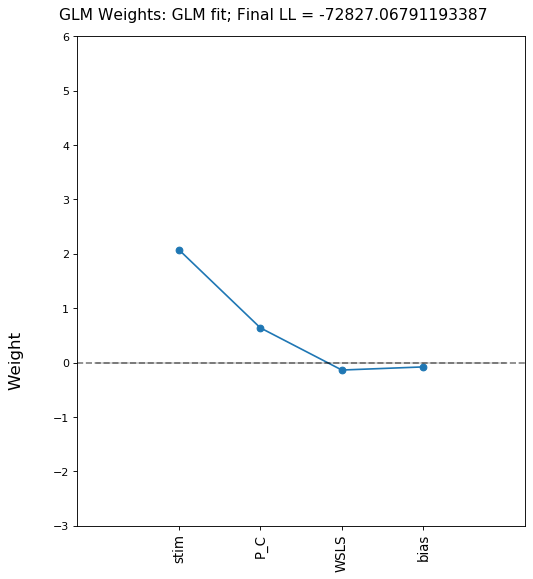

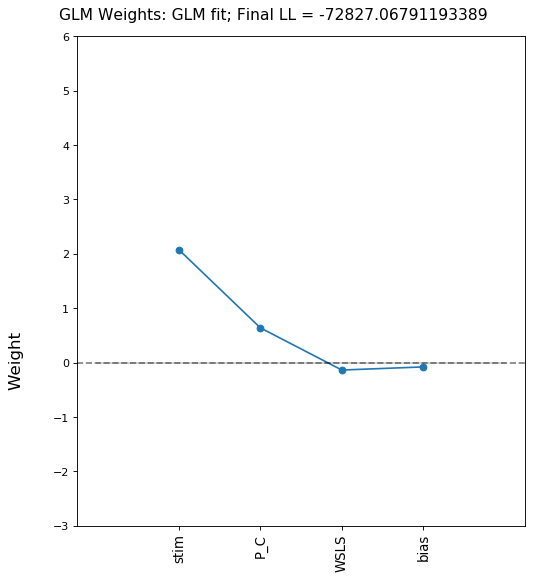

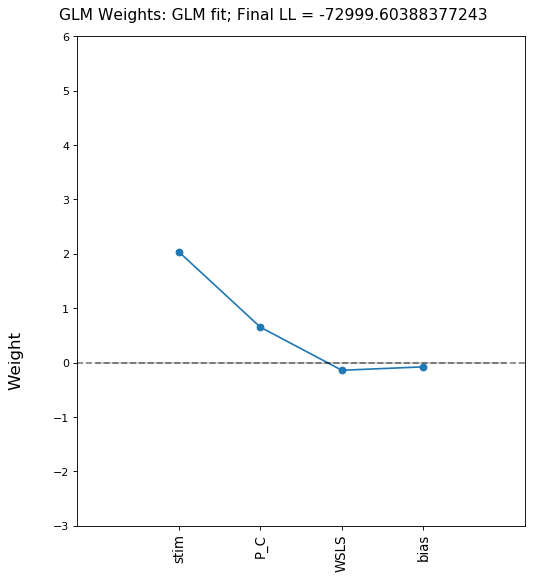

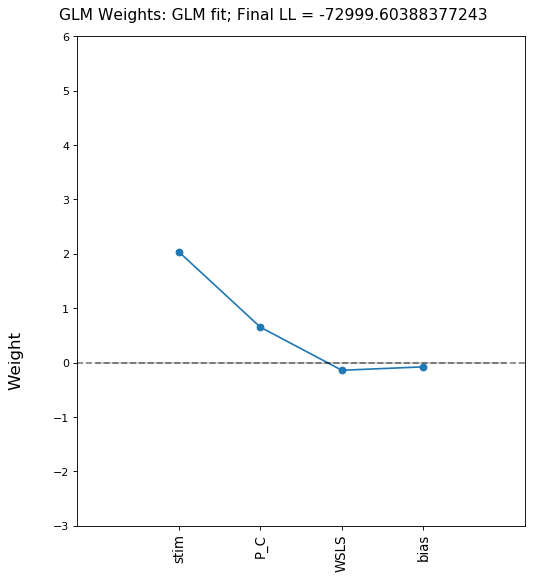

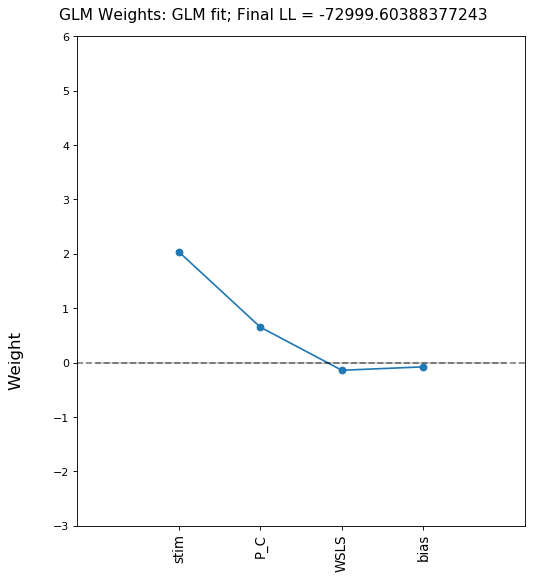

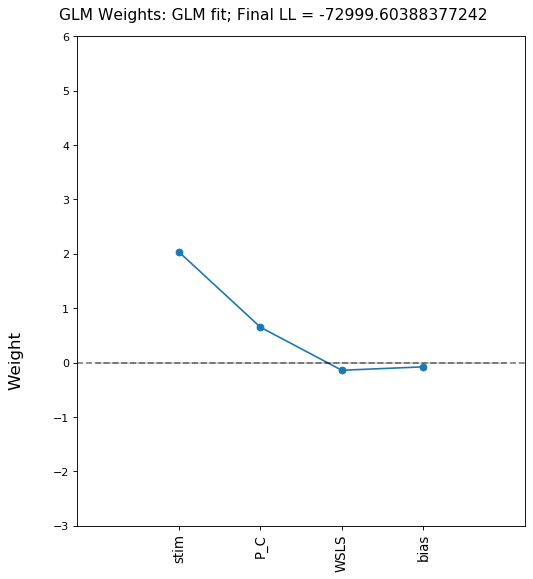

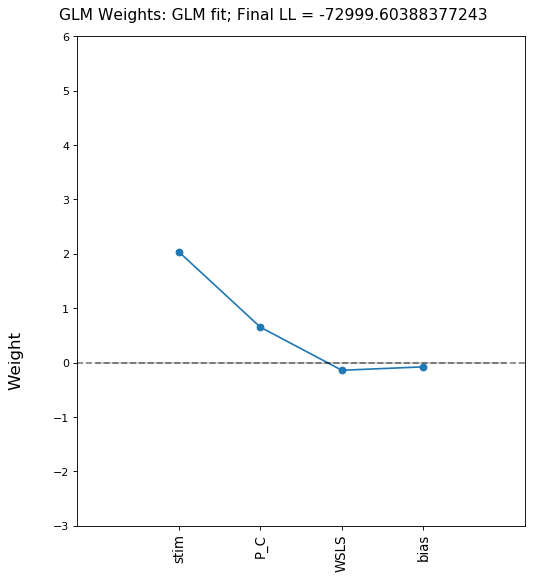

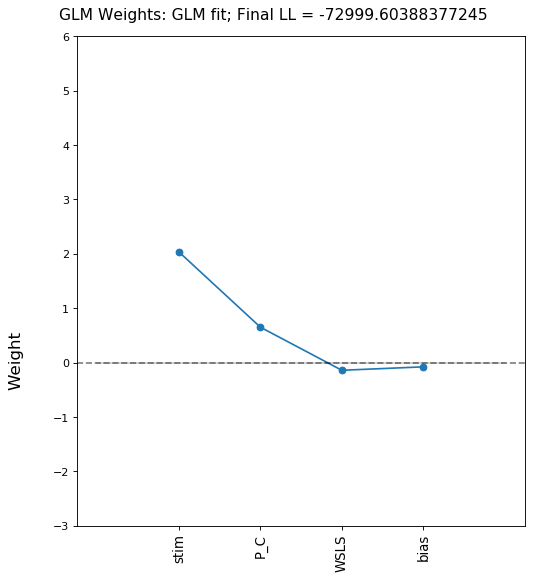

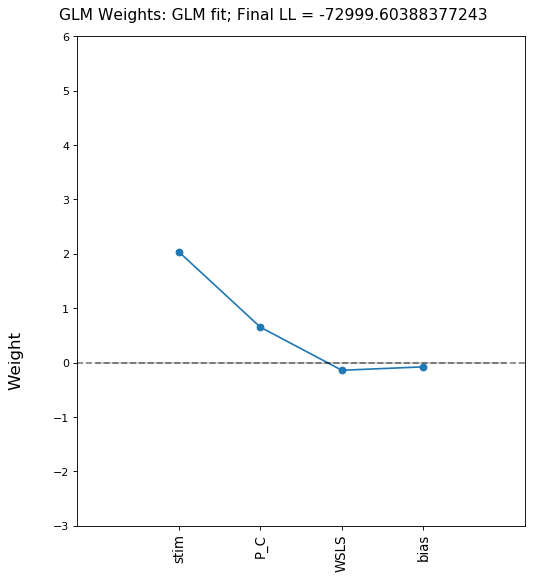

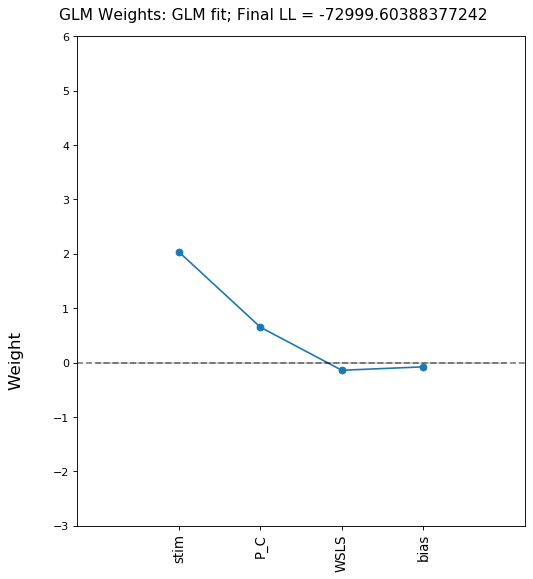

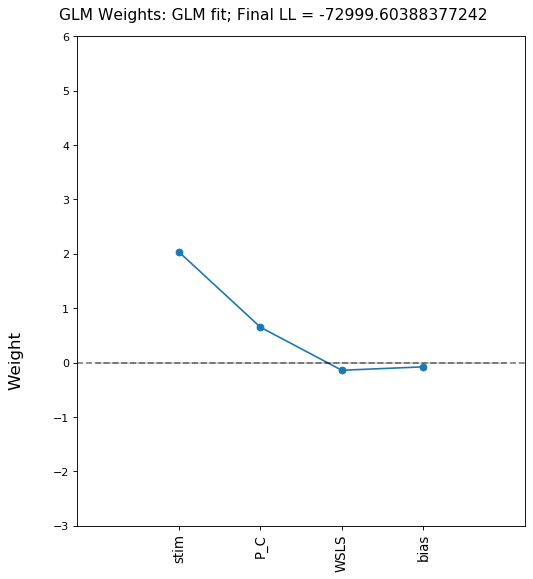

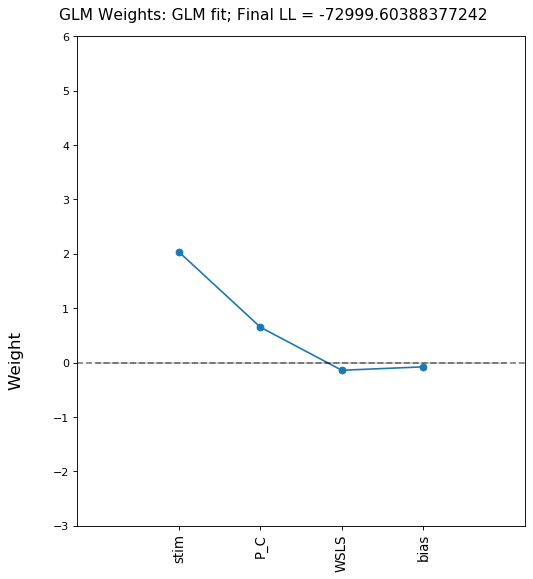

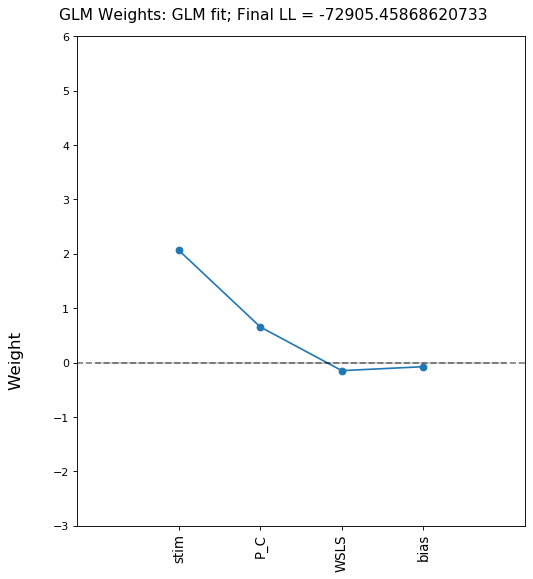

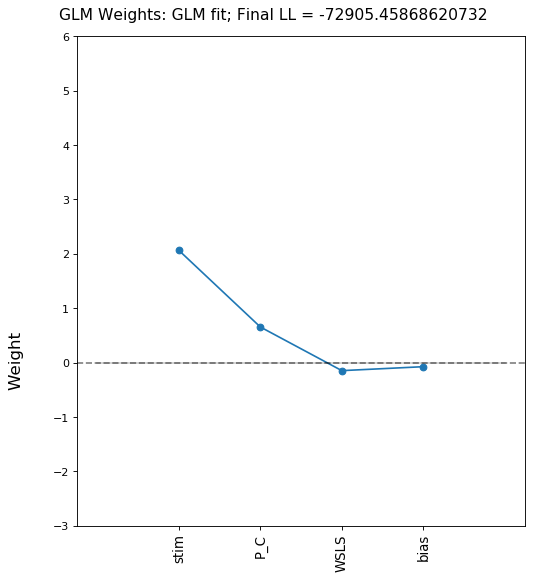

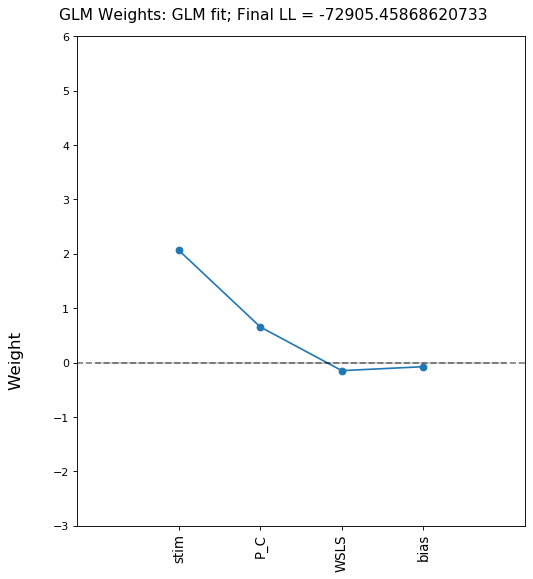

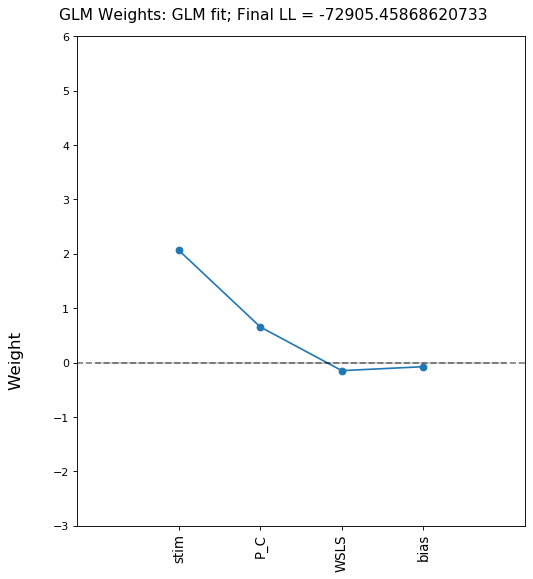

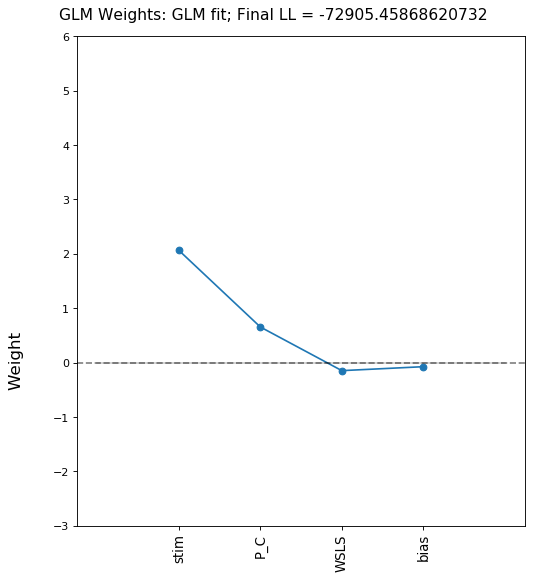

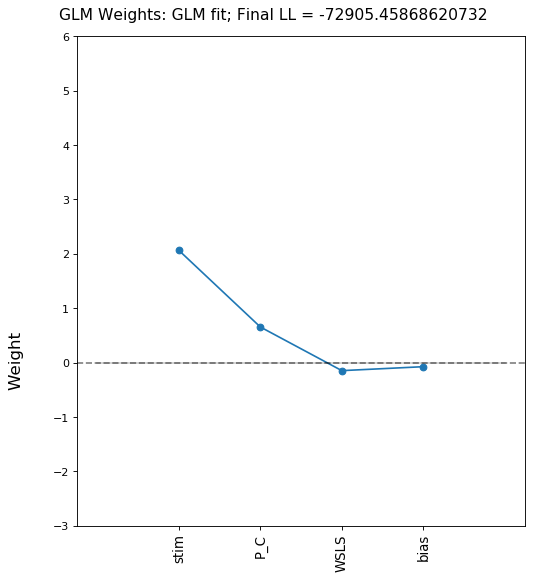

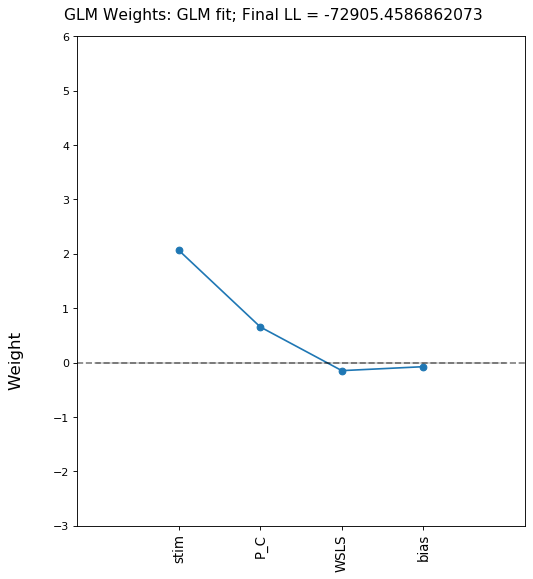

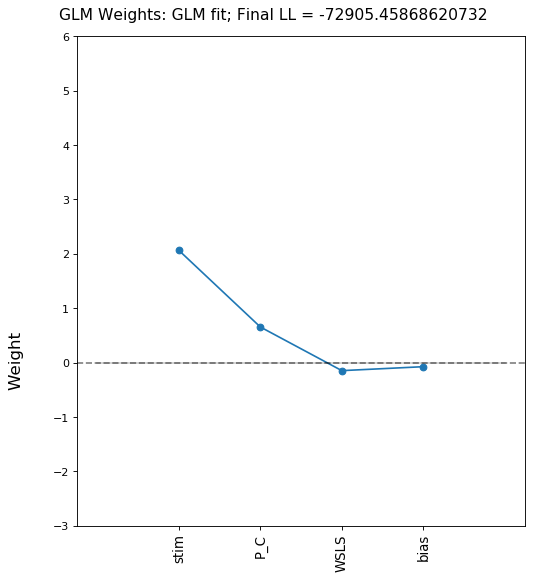

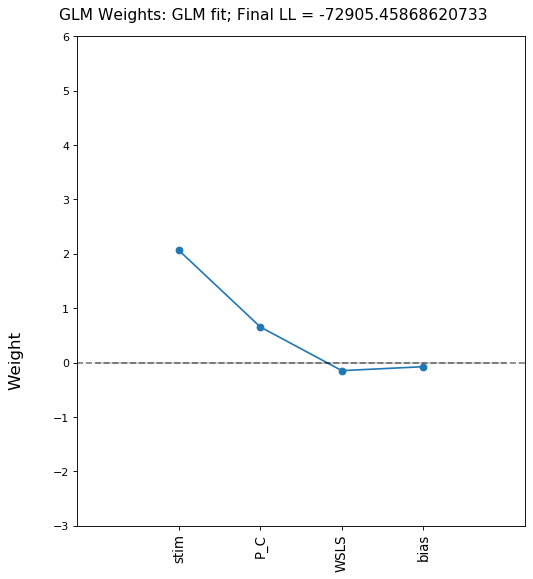

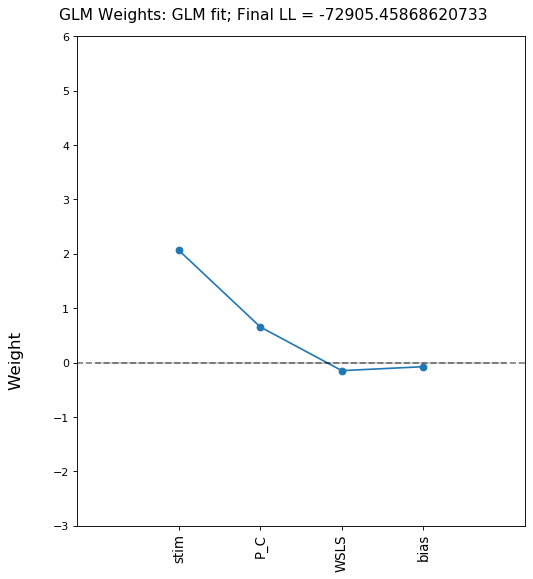

In [4]:
C = 2  # number of output types/categories
N_initializations = 10

data_dir = '../../data/ibl/data_for_cluster/'
num_folds = 5

# Create directory for results:
results_dir = '../../results/ibl_global_fit/'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Fit GLM to all data
animal_file = data_dir + 'all_animals_concat.npz'
inpt, y, session = load_data(animal_file)
session_fold_lookup_table = load_session_fold_lookup(
    data_dir + 'all_animals_concat_session_fold_lookup.npz')

for fold in range(num_folds):
    # Subset to relevant covariates for covar set of interest:
    labels_for_plot = ['stim', 'P_C', 'WSLS', 'bias']
    y = y.astype('int')
    figure_directory = results_dir + "GLM/fold_" + str(fold) + '/'
    if not os.path.exists(figure_directory):
        os.makedirs(figure_directory)

    # Subset to sessions of interest for fold
    sessions_to_keep = session_fold_lookup_table[np.where(
        session_fold_lookup_table[:, 1] != fold), 0]
    idx_this_fold = [
        str(sess) in sessions_to_keep and y[id, 0] != -1
        for id, sess in enumerate(session)
    ]
    this_inpt, this_y, this_session = inpt[idx_this_fold, :], y[
        idx_this_fold, :], session[idx_this_fold]
    assert len(
        np.unique(this_y)
    ) == 2, "choice vector should only include 2 possible values"
    train_size = this_inpt.shape[0]

    M = this_inpt.shape[1]
    loglikelihood_train_vector = []

    for iter in range(N_initializations):  # GLM fitting should be
        # independent of initialization, so fitting multiple
        # initializations is a good way to check that everything is
        # working correctly
        loglikelihood_train, recovered_weights = fit_glm([this_inpt],
                                                            [this_y], M, C)
        weights_for_plotting = append_zeros(recovered_weights)
        plot_input_vectors(weights_for_plotting,
                            figure_directory,
                            title="GLM fit; Final LL = " +
                            str(loglikelihood_train),
                            save_title='init' + str(iter),
                            labels_for_plot=labels_for_plot)
        loglikelihood_train_vector.append(loglikelihood_train)
        np.savez(
            figure_directory + 'variables_of_interest_iter_' + str(iter) +
            '.npz', loglikelihood_train, recovered_weights)